#  House Price Prediction

## Project Overview

The objective of this project is to build a machine learning model that predicts house prices using the Ames Housing dataset.

The project follows the complete machine learning workflow, including:

- Data loading and exploration
- Data cleaning and handling missing values
- Exploratory Data Analysis (EDA)
- Feature engineering
- Data preprocessing
- Model training
- Model evaluation

The performance of multiple regression models is compared to identify the best-performing model.

In [2]:
import pandas as pd
df=pd.read_csv("C:\\Users\\Rishab vishwakarma\\Downloads\\archive (2)\\train.csv")
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


# Data Cleaning

Real-world datasets often contain missing values and inconsistent data.

In this section, missing values are handled using suitable techniques depending on the type of feature. Numerical and categorical variables are treated separately to prepare the dataset for machine learning.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [4]:
df.isnull().sum().sum()

np.int64(7829)

In [5]:
df.isnull().values.any()

np.True_

In [6]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [7]:
df['GarageQual'].value_counts

<bound method IndexOpsMixin.value_counts of 0       TA
1       TA
2       TA
3       TA
4       TA
        ..
1455    TA
1456    TA
1457    TA
1458    TA
1459    TA
Name: GarageQual, Length: 1460, dtype: str>

In [8]:
df['Alley']=df['Alley'].fillna('No Alley')
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,No Alley,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,No Alley,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,No Alley,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,No Alley,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,No Alley,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,No Alley,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,No Alley,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,No Alley,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,No Alley,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [9]:
df['PoolQC']=df['PoolQC'].fillna('No Pool')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,No Alley,Reg,Lvl,AllPub,...,0,No Pool,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,No Alley,Reg,Lvl,AllPub,...,0,No Pool,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,No Alley,IR1,Lvl,AllPub,...,0,No Pool,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,No Alley,IR1,Lvl,AllPub,...,0,No Pool,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,No Alley,IR1,Lvl,AllPub,...,0,No Pool,NaN,NaN,0,12,2008,WD,Normal,250000


In [10]:
df['Fence']=df['Fence'].fillna('No Fence')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,No Alley,Reg,Lvl,AllPub,...,0,No Pool,No Fence,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,No Alley,Reg,Lvl,AllPub,...,0,No Pool,No Fence,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,No Alley,IR1,Lvl,AllPub,...,0,No Pool,No Fence,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,No Alley,IR1,Lvl,AllPub,...,0,No Pool,No Fence,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,No Alley,IR1,Lvl,AllPub,...,0,No Pool,No Fence,NaN,0,12,2008,WD,Normal,250000


In [11]:
df['MiscFeature']=df['MiscFeature'].fillna('None')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,No Alley,Reg,Lvl,AllPub,...,0,No Pool,No Fence,None,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,No Alley,Reg,Lvl,AllPub,...,0,No Pool,No Fence,None,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,No Alley,IR1,Lvl,AllPub,...,0,No Pool,No Fence,None,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,No Alley,IR1,Lvl,AllPub,...,0,No Pool,No Fence,None,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,No Alley,IR1,Lvl,AllPub,...,0,No Pool,No Fence,None,0,12,2008,WD,Normal,250000


In [12]:
df['LotFrontage']=df['LotFrontage'].fillna(df['LotFrontage'].median())
df.head()
df['LotFrontage'].isnull().sum()

np.int64(0)

In [13]:
df['MSZoning'].value_counts()

MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

In [14]:
df['PoolQC'].value_counts()

PoolQC
No Pool    1453
Gd            3
Ex            2
Fa            2
Name: count, dtype: int64

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          1460 non-null   str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [16]:
df.isnull().sum()

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 81, dtype: int64

In [17]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,No Alley,Reg,Lvl,AllPub,...,0,No Pool,No Fence,None,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,No Alley,Reg,Lvl,AllPub,...,0,No Pool,No Fence,None,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,No Alley,IR1,Lvl,AllPub,...,0,No Pool,No Fence,None,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,No Alley,IR1,Lvl,AllPub,...,0,No Pool,No Fence,None,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,No Alley,IR1,Lvl,AllPub,...,0,No Pool,No Fence,None,0,12,2008,WD,Normal,250000


In [18]:
df.isnull().sum().sort_values(ascending=True)

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
              ... 
GarageType      81
GarageQual      81
GarageYrBlt     81
FireplaceQu    690
MasVnrType     872
Length: 81, dtype: int64

In [19]:
df['GarageYrBlt']=df['GarageYrBlt'].fillna(0)
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,No Alley,Reg,Lvl,AllPub,...,0,No Pool,No Fence,None,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,No Alley,Reg,Lvl,AllPub,...,0,No Pool,No Fence,None,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,No Alley,IR1,Lvl,AllPub,...,0,No Pool,No Fence,None,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,No Alley,IR1,Lvl,AllPub,...,0,No Pool,No Fence,None,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,No Alley,IR1,Lvl,AllPub,...,0,No Pool,No Fence,None,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,No Alley,Reg,Lvl,AllPub,...,0,No Pool,No Fence,None,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,No Alley,Reg,Lvl,AllPub,...,0,No Pool,MnPrv,None,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,No Alley,Reg,Lvl,AllPub,...,0,No Pool,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,No Alley,Reg,Lvl,AllPub,...,0,No Pool,No Fence,None,0,4,2010,WD,Normal,142125


In [20]:
df['GarageFinish']=df['GarageFinish'].fillna('None')
df['GarageQual']=df['GarageQual'].fillna('None')
df['MasVnrType']=df['MasVnrType'].fillna(0)


In [21]:
df.isnull().sum().sort_values(ascending=True)
df['BsmtExposure']=df['BsmtExposure'].fillna('None')


In [22]:
df.isnull().sum().sort_values(ascending=True)
#df['BsmtFinType1']=df['BsmtFinType'].fillna('None')
df['BsmtFinType2']=df['BsmtFinType2'].fillna('None')
df['GarageCond']=df['GarageCond'].fillna('None')
df['FireplaceQu']=df['FireplaceQu'].fillna('None')

In [23]:
df.isnull().sum().sort_values(ascending=True)

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MasVnrArea       8
BsmtFinType1    37
BsmtQual        37
BsmtCond        37
GarageType      81
Length: 81, dtype: int64

In [24]:
df['BsmtFinType1']=df['BsmtFinType1'].fillna('None')
df['BsmtCond']=df['BsmtCond'].fillna('None')
df['BsmtQual']=df['BsmtQual'].fillna('None')

In [25]:
df.isnull().sum().sort_values(ascending=True)
df['Electrical']=df['Electrical'].fillna('None')

In [26]:
df.isnull().sum().sort_values(ascending=True)
df['MasVnrArea']=df['MasVnrArea'].fillna('None')

In [27]:
df.isnull().sum().sort_values(ascending=True)
df['Alley']=df['Alley'].fillna('No Alley')

In [28]:
df.isnull().sum().sort_values(ascending=True)

Id                0
MSSubClass        0
MSZoning          0
LotFrontage       0
LotArea           0
                 ..
MoSold            0
YrSold            0
SaleType          0
SaleCondition     0
GarageType       81
Length: 81, dtype: int64

In [29]:
df.columns
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,No Alley,Reg,Lvl,AllPub,...,0,No Pool,No Fence,None,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,No Alley,Reg,Lvl,AllPub,...,0,No Pool,No Fence,None,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,No Alley,IR1,Lvl,AllPub,...,0,No Pool,No Fence,None,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,No Alley,IR1,Lvl,AllPub,...,0,No Pool,No Fence,None,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,No Alley,IR1,Lvl,AllPub,...,0,No Pool,No Fence,None,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,No Alley,Reg,Lvl,AllPub,...,0,No Pool,No Fence,None,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,No Alley,Reg,Lvl,AllPub,...,0,No Pool,MnPrv,None,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,No Alley,Reg,Lvl,AllPub,...,0,No Pool,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,No Alley,Reg,Lvl,AllPub,...,0,No Pool,No Fence,None,0,4,2010,WD,Normal,142125


In [30]:
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,No Alley,Reg,Lvl,AllPub,...,0,No Pool,No Fence,None,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,No Alley,Reg,Lvl,AllPub,...,0,No Pool,No Fence,None,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,No Alley,IR1,Lvl,AllPub,...,0,No Pool,No Fence,None,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,No Alley,IR1,Lvl,AllPub,...,0,No Pool,No Fence,None,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,No Alley,IR1,Lvl,AllPub,...,0,No Pool,No Fence,None,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,No Alley,Reg,Lvl,AllPub,...,0,No Pool,No Fence,None,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,No Alley,Reg,Lvl,AllPub,...,0,No Pool,MnPrv,None,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,No Alley,Reg,Lvl,AllPub,...,0,No Pool,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,No Alley,Reg,Lvl,AllPub,...,0,No Pool,No Fence,None,0,4,2010,WD,Normal,142125


In [31]:
df['3SsnPorch'].value_counts
df['ScreenPorch'].value_counts

<bound method IndexOpsMixin.value_counts of 0       0
1       0
2       0
3       0
4       0
       ..
1455    0
1456    0
1457    0
1458    0
1459    0
Name: ScreenPorch, Length: 1460, dtype: int64>

In [32]:
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,No Alley,Reg,Lvl,AllPub,...,0,No Pool,No Fence,None,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,No Alley,Reg,Lvl,AllPub,...,0,No Pool,No Fence,None,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,No Alley,IR1,Lvl,AllPub,...,0,No Pool,No Fence,None,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,No Alley,IR1,Lvl,AllPub,...,0,No Pool,No Fence,None,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,No Alley,IR1,Lvl,AllPub,...,0,No Pool,No Fence,None,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,No Alley,Reg,Lvl,AllPub,...,0,No Pool,No Fence,None,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,No Alley,Reg,Lvl,AllPub,...,0,No Pool,MnPrv,None,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,No Alley,Reg,Lvl,AllPub,...,0,No Pool,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,No Alley,Reg,Lvl,AllPub,...,0,No Pool,No Fence,None,0,4,2010,WD,Normal,142125


In [33]:
df['RoofMatl'].value_counts
df['GarageFinish'].value_counts
df['WoodDeckSF'].value_counts
df['OpenPorchSF'].value_counts

<bound method IndexOpsMixin.value_counts of 0       61
1        0
2       42
3       35
4       84
        ..
1455    40
1456     0
1457    60
1458     0
1459    68
Name: OpenPorchSF, Length: 1460, dtype: int64>

In [34]:
pd.set_option('display.max_columns',None)
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,No Alley,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,None,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,No Pool,No Fence,None,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,No Alley,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,0,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,No Pool,No Fence,None,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,No Alley,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,No Pool,No Fence,None,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,No Alley,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,0,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,No Pool,No Fence,None,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,No Alley,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,No Pool,No Fence,None,0,12,2008,WD,Normal,250000


# Exploratory Data Analysis (EDA)

The purpose of Exploratory Data Analysis is to understand the dataset and identify patterns, relationships, and potential issues before building machine learning models.

Different visualizations are used to analyze the distribution of variables and their relationship with the target variable (SalePrice).

The scatter plot shows a strong positive relationship between ground living area and saleprice.As the living area increases,the saleprice also increases.A few outliers are observed,which may affect model performance.Log transformation was applied to stabilize variance and improve distribution

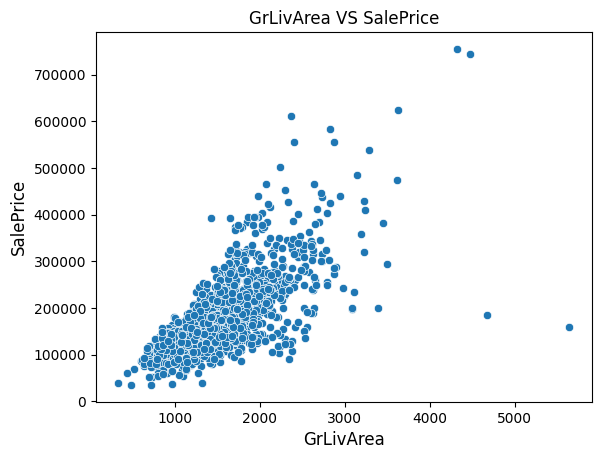

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
#grouping data
sns.scatterplot(x='GrLivArea',y='SalePrice',data=df)
plt.title("GrLivArea VS SalePrice")
plt.xlabel('GrLivArea',fontsize=12)
plt.ylabel('SalePrice',fontsize=12)
plt.show()

The bar chart represent the top 10 most expensive houses in the dataset.Each bar corresponds  to a house,and its height indicates the saleprice.The graph shows that a few houses  have significantly higher prices compared to others,indicating variability in property value

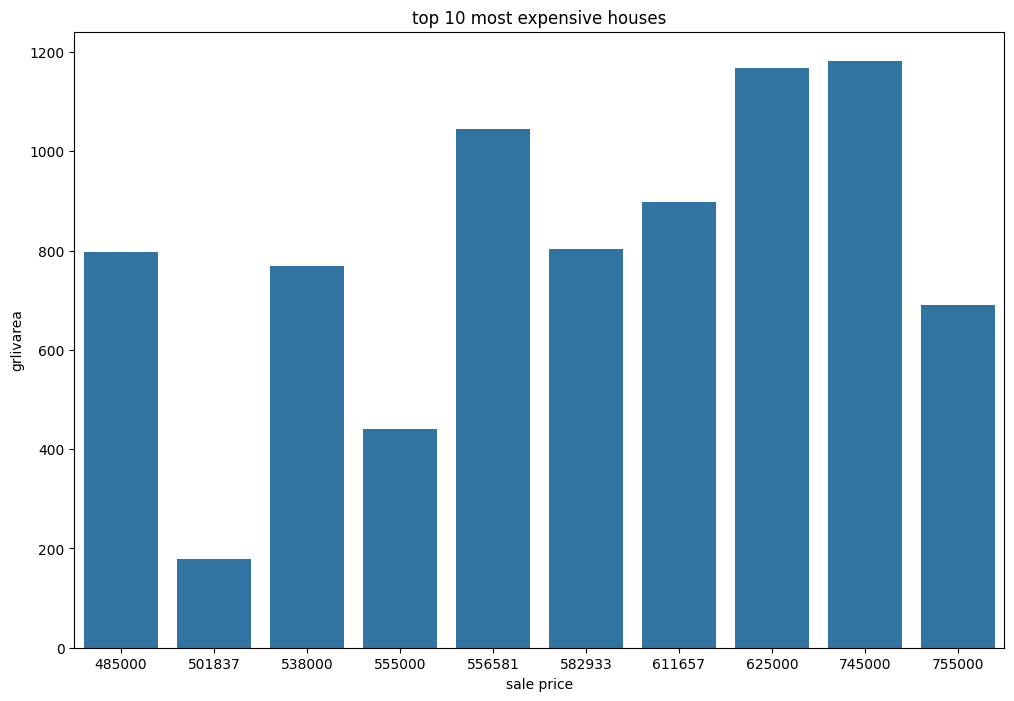

In [36]:

total_sf=df.sort_values(by='SalePrice',ascending=False).head(10)
total_sf['SalePrice']=total_sf['SalePrice'].round(0)
plt.figure(figsize=(12,8))
sns.barplot(x=total_sf['SalePrice'],y=total_sf.index)
plt.title('top 10 most expensive houses')
plt.xlabel('sale price')
plt.ylabel('grlivarea')
plt.show()

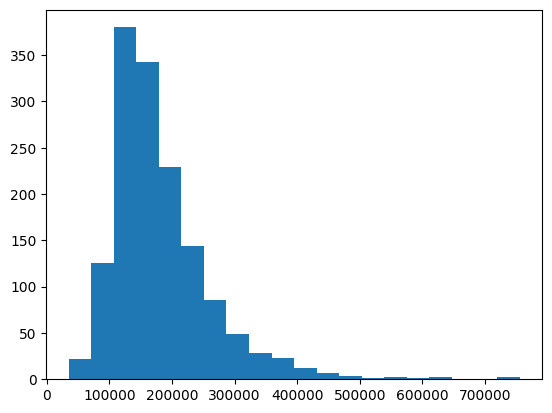

In [37]:
import matplotlib.pyplot as plt
plt.hist(df['SalePrice'],bins=20)
plt.show()

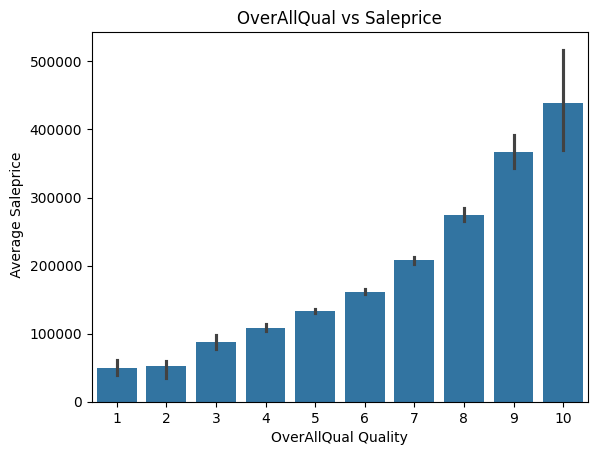

In [38]:
sns.barplot(x='OverallQual',y='SalePrice',data=df)
plt.title('OverAllQual vs Saleprice')
plt.xlabel('OverAllQual Quality')
plt.ylabel(' Average Saleprice')
plt.show()

In [39]:
print(df['SalePrice'].head())

0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64


In [40]:
print(df['SalePrice'].head())
print(df['SalePrice'].describe())

0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


# Model Building

After preprocessing the dataset, regression models are trained to predict house prices.

The objective is to compare different algorithms and identify the model that provides the best predictive performance.

## Linear Regression Model

Linear Regression is used as the baseline model for predicting house sale prices.

The model assumes that there is a linear relationship between the input features and the target variable, `SalePrice`.

I used Linear Regression as the baseline because it provides a simple model that can be compared with a more complex machine learning model such as Random Forest.

The preprocessing steps, including categorical feature encoding, are handled using a Scikit-learn Pipeline and ColumnTransformer.

### Model Evaluation

The Linear Regression model is evaluated using Mean Absolute Error (MAE) and R² score.

- **MAE:** Measures the average absolute difference between the actual and predicted sale prices. Lower values indicate better performance.
- **R² Score:** Measures how well the model explains the variation in the target variable. A higher value indicates better performance.

The results provide a baseline for comparison with the Random Forest model.

In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score,mean_absolute_error
cat_cols=['GarageType','Neighborhood','MSZoning','LotConfig','GarageQual']
nums_cols=['YrSold','MoSold','YearBuilt','OverallQual','GrLivArea','TotalBsmtSF','BsmtFullBath',
           'BsmtHalfBath','YearRemodAdd','GarageArea']
X=df[cat_cols+nums_cols]
Y=np.log(df['SalePrice'])
preprocessor=ColumnTransformer(
    transformers=[
        ('cat',OneHotEncoder(handle_unknown='ignore'),cat_cols)
    ],
    remainder='passthrough'
)
pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ('model',LinearRegression())
])
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
pipeline.fit(x_train,y_train)
y_pred=pipeline.predict(x_test)
comparison=pd.DataFrame({
    'actual':y_test,
    'predicted':y_pred
})
print(comparison.head)
print("r2 score is:",r2_score(y_test,y_pred))
print("mean_absolute_error:",mean_absolute_error(y_test,y_pred))

<bound method NDFrame.head of          actual  predicted
892   11.947949  11.924315
1105  12.691580  12.696433
413   11.652687  11.507746
522   11.976659  11.839065
1036  12.661914  12.622209
...         ...        ...
479   11.401670  11.636970
1361  12.468437  12.395546
802   12.149502  12.217055
651   11.589887  11.575400
722   11.732061  11.582177

[292 rows x 2 columns]>
r2 score is: 0.8922662020573262
mean_absolute_error: 0.10223599696602285


### Linear Regression Results

The Linear Regression model achieved an R² score of [0.8922662020573262] and an MAE of [0.10223599696602285] on the test dataset.

These results will be compared with the Random Forest Regressor to determine which model performs better for this dataset.

In [42]:
import pickle
pickle.dump(pipeline,open("model.pkl","wb"))

### Random Forest Regressor

Random Forest is an ensemble learning algorithm that combines multiple decision trees.

Each tree makes a prediction, and the final prediction is obtained by averaging the outputs of all trees.

Random Forest is capable of capturing non-linear relationships and is generally more robust than a single decision tree.

### Random Forest Model Evaluation

The Random Forest model is evaluated using the same metrics used for Linear Regression:

- **Mean Absolute Error (MAE):** Lower values indicate smaller prediction errors.
- **R² Score:** Higher values indicate that the model explains more of the variation in `SalePrice`.

Using the same evaluation metrics allows a direct comparison between the two models.

In [43]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score,mean_absolute_error
cat_cols=['GarageType','Neighborhood','MSZoning','LotConfig','GarageQual']
nums_cols=['YrSold','MoSold','YearBuilt','OverallQual','GrLivArea','TotalBsmtSF','BsmtFullBath',
           'BsmtHalfBath','YearRemodAdd','GarageArea']
X=df[cat_cols+nums_cols]
Y=np.log(df['SalePrice'])
preprocessor=ColumnTransformer(
    transformers=[
        ('cat',OneHotEncoder(handle_unknown='ignore'),cat_cols)
    ],
    remainder='passthrough'
)
pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ('model',RandomForestRegressor())
])
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
pipeline.fit(x_train,y_train)
y_pred=pipeline.predict(x_test)
comparison=pd.DataFrame({
    'actual':y_test,
    'predicted':y_pred
})
print(comparison.head)
print("r2 score is:",r2_score(y_test,y_pred))
print("mean_absolute_error:",mean_absolute_error(y_test,y_pred))


<bound method NDFrame.head of          actual  predicted
892   11.947949  11.828628
1105  12.691580  12.688278
413   11.652687  11.590059
522   11.976659  11.921614
1036  12.661914  12.658906
...         ...        ...
479   11.401670  11.719246
1361  12.468437  12.315735
802   12.149502  12.134044
651   11.589887  11.690689
722   11.732061  11.632689

[292 rows x 2 columns]>
r2 score is: 0.8664854439948566
mean_absolute_error: 0.10584812242844248


### Random Forest Results

The Random Forest Regressor achieved an R² score of [0.8660365534247949] and an MAE of [0.10634166883687507] on the test dataset.

The performance of this model is compared with the Linear Regression baseline to determine which approach is more suitable for predicting house sale prices.

In [44]:
df['GarageArea'].value_counts

<bound method IndexOpsMixin.value_counts of 0       548
1       460
2       608
3       642
4       836
       ... 
1455    460
1456    500
1457    252
1458    240
1459    276
Name: GarageArea, Length: 1460, dtype: int64>

## Random Forest Regressor for Overall Quality Prediction

In addition to predicting `SalePrice`, I used a Random Forest Regressor to predict `OverallQual`.

`OverallQual` represents the overall quality and finish of the house. The purpose of this experiment was to explore whether other housing characteristics could be used to predict the overall quality of a house.

Random Forest Regressor was selected because it can capture nonlinear relationships and interactions between different features.

The categorical features were encoded using `OneHotEncoder`, while the preprocessing and model were combined using a Scikit-learn `Pipeline`.

In [45]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_absolute_error
import numpy as np
import pandas as pd
categorical_cols=['MSZoning','Neighborhood','SaleCondition','BldgType','BsmtQual','Foundation',
                  'GarageCond','KitchenQual','HeatingQC','ExterQual','RoofStyle',
                  'RoofMatl','LotConfig','GarageFinish']
numerical_cols=['LotArea','GrLivArea','YearBuilt','OverallCond','TotalBsmtSF','BsmtFullBath',
               'FullBath','HalfBath','GarageArea','TotRmsAbvGrd','GarageCars','SalePrice']
X=df[categorical_cols+numerical_cols]
Y=df['OverallQual']
preprocessor=ColumnTransformer(
    transformers=[
        ('cat',OneHotEncoder(handle_unknown='ignore'),categorical_cols)
    ],
    remainder='passthrough'
)
pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ('model',RandomForestRegressor())
])
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
pipeline.fit(x_train,y_train)
y_pred=pipeline.predict(x_test)
comparison=pd.DataFrame({
    'actual':y_test,
    'predicted':y_pred
})
print(comparison.head())
print("r2 score is:",r2_score(y_test,y_pred))
print("mean_absolute_error:",mean_absolute_error(y_test,y_pred))
import pickle
pickle.dump(pipeline,open("model2.pkl","wb"))

      actual  predicted
892        6       5.40
1105       8       8.21
413        5       5.03
522        6       5.84
1036       9       8.51
r2 score is: 0.8108980116393969
mean_absolute_error: 0.4647323059360731


### Results

The Random Forest Regressor achieved an R² score of [0.803834272206529] and an MAE of [0.47229223744292237] on the test dataset.

This experiment demonstrates the use of Random Forest for predicting a different target variable from the same housing dataset.

In [46]:
import pickle
pickle.dump(pipeline,open("model2.pkl","wb"))

In [47]:
 #Model Comparison

| Model | Target | R² Score |
|---|---|---:|
| Linear Regression | SalePrice | 0.8923 |
| Random Forest Regressor | SalePrice | 0.86 |
| Random Forest Regressor | OverallQual | 0.8088 |

#Final Model Selection





SyntaxError: invalid character '²' (U+00B2) (2004876346.py, line 3)

## Conclusion

In this project, I developed machine learning models to predict house 'SalePrice' using the Ames Housing dataset.

Two regression models were evaluated for 'SalePrice' prediction: Linear Regression and Random Forest Regressor. Linear Regression achieved an R² score of **0.8923**, while Random Forest Regressor achieved an R² score of approximately **0.86**.

Since Linear Regression achieved a higher R² score on the test dataset, it performed better than Random Forest for this particular dataset and preprocessing approach. Therefore, I selected **Linear Regression as the final model** for 'SalePrice' prediction.

The results show that a more complex model does not always perform better than a simpler model. Instead, the final model should be selected based on its performance on the evaluation data.

As an additional experiment, I also used Random Forest Regressor to predict OverallQual to explore another prediction task using the housing dataset.